# Audio Processing: Mel-Spectrograms

Denne notebooken utforsker det auditive domenet ($U_{audio}$) som beskrevet i `architecture-manifest.md`. Vi bruker mel-spektrogrammer for å representere lydsignalet. Dette er et viktig skritt for å kunne koble auditive observasjoner (som transients/onsets og harmoniske strukturer) til den felles sannheten ($D$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Sett opp figurstørrelse for plot
plt.rcParams['figure.figsize'] = (12, 4)

## 1. Last inn et eksempel på lyd
Vi bruker en innebygd lydfil fra `librosa` for å demonstrere. I prosjektet vil dette byttes ut med opptak av musikken som skal analyseres.

In [2]:
# Laster inn en trompet-lyd som eksempel (librosa.ex laster ned eller bruker cachet fil)
# Bytt ut med stien til en faktisk lydfil, f.eks. 'data/audio.wav' senere.
y, sr = librosa.load(librosa.ex('trumpet'))

print(f"Sample rate: {sr} Hz")
print(f"Varighet: {len(y)/sr:.2f} sekunder")

Sample rate: 22050 Hz
Varighet: 5.33 sekunder


## 2. Beregn Mel-Spektrogram

Mel-spektrogrammet gir en representasjon av lyden der frekvensaksen er logaritmisk (mel-skalaen), noe som passer bedre overens med menneskets hørsel og musikalsk pitch ($p$). Dette er vårt observasjonsgrunnlag for $D_{onset}$ og $D_{sustain}$.

In [3]:
# Beregn mel-spektrogram
n_fft = 2048
hop_length = 512
n_mels = 128

S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)

# Konverter amplitude til desibel (dB) for logaritmisk visualisering
S_dB = librosa.power_to_db(S, ref=np.max)

## 3. Visualisering

Vi plotter resultatet for å kunne inspisere energidistribusjonen over tid ($t$) og frekvens ($p$). Energitopper her kan senere brukes til å oppdatere priors i $D$ (Sensor Fusion).

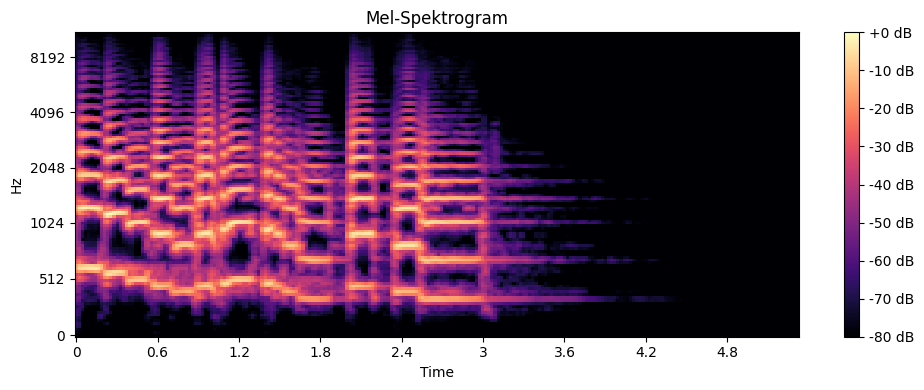

In [4]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spektrogram')
plt.tight_layout()
plt.show()

## 4. Neste steg: Mot Sensor Fusion ($D$)

For å integrere dette med OMR (det visuelle) slik arkitekturen beskriver:
1. **$D_{onset}(t, p)$:** Finne auditive onsets (anslag) ved å se på raske energiøkninger i spesifikke mel-bånd over tid.
2. **$D_{sustain}(t, p)$:** Identifisere vedvarende horisontale bånd i spektrogrammet (harmonisk struktur).

Dette grid-et (spektrogrammet) fungerer som den auditive projeksjonen ($U_{audio}$), og korrelerer direkte med $D_{onset}$ og $D_{sustain}$.